In [1]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import gc
from pathlib import Path
from define_data_and_variables import hmc_config, hmc_hash, data, version

In [2]:
base_dir = Path.cwd()
base_path = base_dir / ".." / ".." / ".." / ".." / "data"

print(data["dn"].lower())
data_name = rf"$A_{{{data["dn"][:3]}}}$"
ylim_max = 0.4
bin_range = (1660, 1730)
true_sample = np.load(base_path / data["dn"] / version / "true_sample.npy")
int_version = int(version)
true_ages = np.hstack((data["th"], data["th"] - np.cumsum(true_sample) * data["dc"]))
c14_label = r"$^{230}$Th" if "d18o" in data["dn"] else r"$^{14}$C"
measure = "mm" if "d18o" in data["dn"] else "cm"

dayu_d18o_edit


In [3]:
base_dir = Path.cwd()
dir = base_dir / f"output/{data["dn"]}/{version}"
output_dir = dir / f"{hmc_hash}"
print(output_dir)

c:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\HMC\output\dayu_d18o_edit\0\42279940c2


In [4]:
color_list = plt.cm.viridis(np.linspace(0, 1, np.min((hmc_config["nch"], 5))))

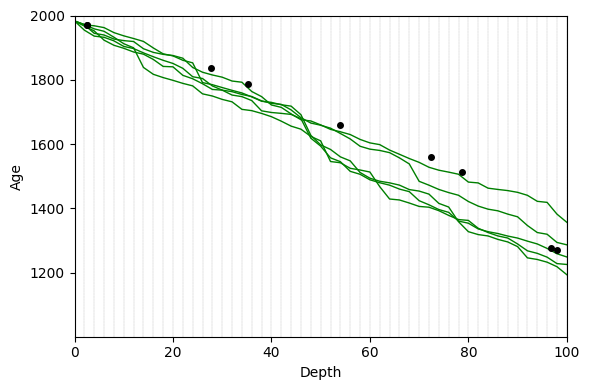

In [5]:

cumulative_sums = np.cumsum(hmc_config["sp"], axis=1) * data["dc"]
zeros = np.zeros((*hmc_config["sp"].shape[:1], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)

model_ages = data["th"] - age_offsets

# Starting points
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(hmc_config["sp"])
for j in range(num_samples):
    ax.plot(
        data["cs"],
        model_ages[j, :],
        color='green',
        alpha=1,
        linewidth=1,
    )
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(np.min(data["d18ort"]), np.max(data["d18ort"]))
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig(f"{dir}/sp_age_depth.jpg")
plt.show()

In [7]:
cutout = 1000
energy_values = np.load(f"{output_dir}/energy.npy", mmap_mode='r')[:, cutout:]


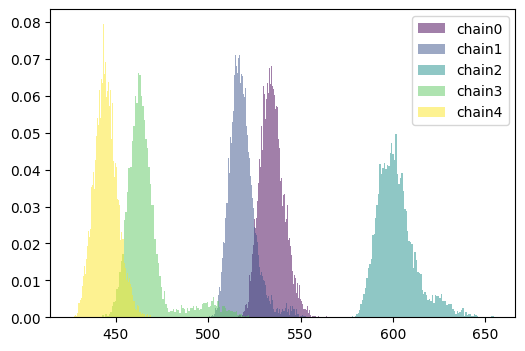

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(np.min((hmc_config["nch"], 5))):
    ax.hist(energy_values[i, cutout:], color = color_list[i], alpha = 0.5, label = f"chain{i}", bins = 100, density = True)
plt.legend()
plt.savefig(f"{output_dir}/energy_hist.jpg")
plt.show()   

In [9]:
print(np.min(energy_values))

426.0520932530759


C:\Users\hanna\AppData\Local\Temp\ipykernel_30284\3310933270.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


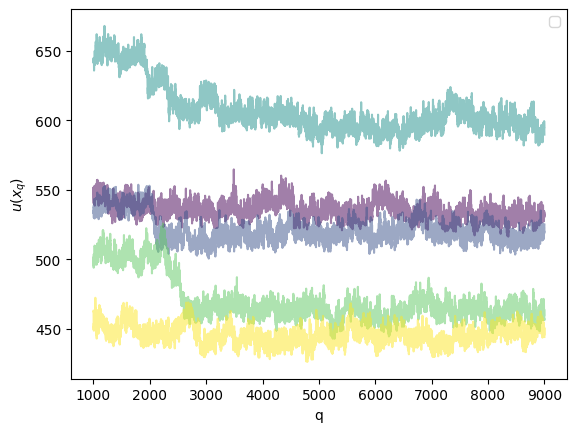

In [10]:
plt.figure()
for i in range(np.min((hmc_config["nch"], 5))):
    plt.plot(np.linspace(cutout, len(energy_values[0, :] + cutout), len(energy_values[i, :])), energy_values[i, :], color = color_list[i], alpha = 0.5)
plt.xlabel("q")
plt.ylabel(r"$u(x_q)$")
plt.legend()
plt.savefig(f"{output_dir}/energy.jpg")
plt.show()

In [11]:
samples = np.load(output_dir / "samples.npy", mmap_mode='r')[:, cutout:, :]

In [12]:
print(az.summary(samples))

         mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
x[0]    9.720   1.437   6.700   10.995      0.628    0.455      10.0   
x[1]    5.345   2.289   0.551    7.331      1.001    0.723      10.0   
x[2]    5.154   1.989   1.119    7.273      0.812    0.520      10.0   
x[3]    3.954   1.687   1.828    6.537      0.406    0.378      15.0   
x[4]   10.952   6.304   5.379   24.129      2.764    1.902       7.0   
x[5]    4.602   2.290   0.870    7.959      0.910    0.175       8.0   
x[6]    6.620   7.545   0.868   22.316      3.259    2.622       9.0   
x[7]   11.252   7.330   1.744   25.422      3.150    1.599       6.0   
x[8]    5.535   3.134   0.717   12.633      0.976    0.625      13.0   
x[9]    5.058   4.044   0.841   14.773      1.622    1.400       8.0   
x[10]   4.389   3.010   1.042   12.515      1.257    1.505       9.0   
x[11]  10.111   5.923   2.506   18.583      2.607    0.630       6.0   
x[12]  11.607  12.826   0.525   36.272      5.719    3.702      

In [13]:
min_energies = [np.min(energy_values, axis = 1)[i] for i in range(hmc_config["nch"])]
min_energy_samples = [samples[i, np.argmin(energy_values, axis = 1)[i], :] for i in range(hmc_config["nch"])]
closest_to_true_samples = [samples[i, np.argmin(np.linalg.norm(samples[i, :, :] - true_sample, axis = 1)), :] for i in range(hmc_config["nch"])]

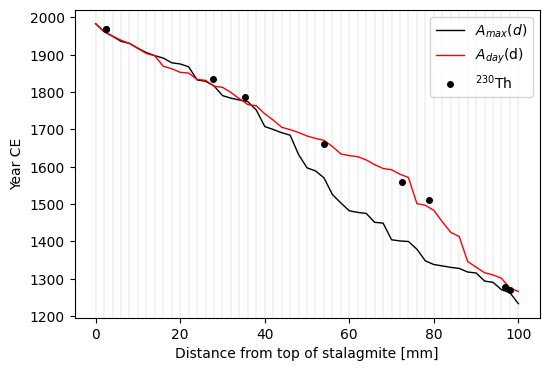

In [14]:
chain = 0
fig, ax = plt.subplots(figsize=(6, 4))
# plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(closest_to_true_samples[chain]))), color = "black", alpha = 1, linewidth = 0.5, label = r"$A_{close}(d)$")
plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(min_energy_samples[chain]))), color = "black", alpha = 1, linewidth = 1, label = r"$A_{max}(d)$")
ax.plot(data["cs"], true_ages, color = "red", linewidth=1, alpha = 1, label = data_name + "(d)")
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
plt.legend()
plt.savefig(f"{output_dir}/close_and_max_prob_sol.jpg")
plt.show()



C:\Users\hanna\AppData\Local\Temp\ipykernel_30284\943572008.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax.errorbar(


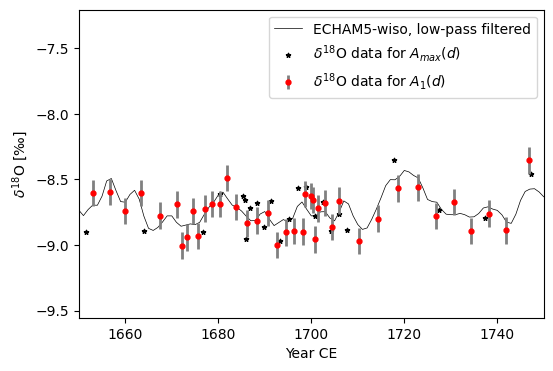

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(data["d18ort"], data["d18or"], color = "black", linewidth = 0.5, label = "ECHAM5-wiso, low-pass filtered")
ax.errorbar(
    data["d18ota"], 
    data["d18o"], 
    yerr=data["d18os"],      
    color="red", 
    ecolor = "grey",
    fmt = ".k", 
    markersize=7,                
    linestyle="None",           
    elinewidth=2,
    label=r"$\delta^{18}$O data for $A_1(d)$"
)

ax.scatter(
    np.interp(data["d18od"], data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(min_energy_samples[chain])))), 
    data["d18o"], 
    color="black", 
    marker="*", 
    s=10,
    label=r"$\delta^{18}$O data for $A_{max}(d)$"
)
plt.xlim((1650, 1750))
plt.ylabel("$\\delta^{18}$O [‰]")
plt.xlabel("Year CE")
plt.legend()
plt.savefig(f"{output_dir}/data_compare.jpg")
plt.show()


In [16]:
chain = 0
index = 12
interesting_depth = index * data["dc"]

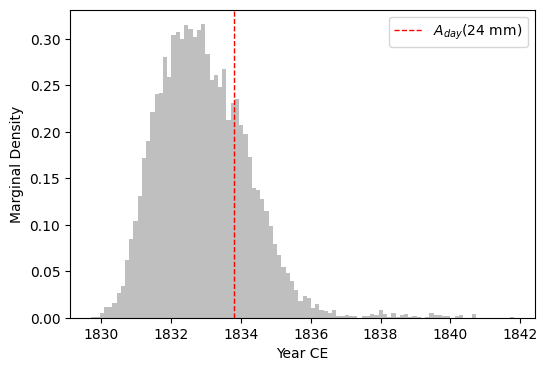

In [17]:
CV_values = data["th"] - data["dc"] * np.sum(samples[chain][:, :index], axis = 1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(CV_values, bins = 100, color = "grey", alpha = 0.5, density=True)
ax.set_xlabel("Year CE")
ax.set_ylabel("Marginal Density")
ax.axvline(x=true_ages[index], color="red", linestyle='--', linewidth = 1, label = data_name + f"({int(interesting_depth)} " + measure + ")")
plt.legend()
plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

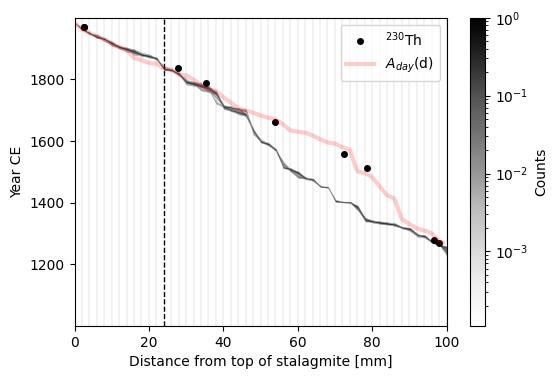

In [18]:
from matplotlib import colors

X = samples[chain].T
D, N = X.shape

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

norm_age = age

# Time bins
dt = 1 if np.max(data["d18ort"]) - np.min(data["d18ort"]) < 2000 else 10
t_edges = np.arange(np.min(data["d18ort"]), np.max(data["d18ort"]) + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = data["H"] / 1000
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for j in range(Z):
    C[j, :], _ = np.histogram(A[j, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    linewidth = 0.1 if i != index else 1
    ax.axvline(x=c, color='k', linestyle='--', linewidth = linewidth)


ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
ax.plot(data["d18od"], data["d18ota"], color = "red", linewidth=3, alpha = 0.2, label = f"{data_name}(d)")

im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    norm=colors.LogNorm()
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Counts")
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
plt.savefig(f"{output_dir}/ad_samples_chain_{chain}.jpg")
plt.show()